In [11]:
%matplotlib widget

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider 

In [13]:
vX = np.linspace(-5, 5, 500)
vX.shape

(500,)

In [14]:
# definition of line function coeficients in the form ax+by+c = 0
a_init = 2.0
b_init = 1.0
c_init = 0.0

vL = np.array([a_init, b_init, c_init]) # vector of line function coefficients
print("Initial form of the equestion: ", vL)
nVal = np.sum(vL[:2] ** 2) ** (0.5)
print(f"The norm of the coefficint [a, b]: {nVal:.2f} ")
vL_norm = vL / nVal # normalized coefficients of the line function
print("Cofficients after normalization: ", vL_norm)
vM = np.array([-vL_norm[0], -vL_norm[2]]) / vL_norm[1]
print("vM form of y = mx + n: ", vM)
vM = np.array([-vL_norm[0], -vL_norm[2]]) / vL_norm[1]
print("vM form of y = mx + n: ", vM)


Initial form of the equestion:  [2. 1. 0.]
The norm of the coefficint [a, b]: 2.24 
Cofficients after normalization:  [0.89442719 0.4472136  0.        ]
vM form of y = mx + n:  [-2. -0.]
vM form of y = mx + n:  [-2. -0.]


In [15]:
def build_line_function(a=a_init, b=b_init, c=c_init): 
    vL = np.array([a, b, c]) # vector of line function coefficients
    print("Initial form of the equestion: ", vL)
    nVal = np.sum(vL[:2] ** 2) ** (0.5)
    print(f"The norm of the coefficint [a, b]: {nVal:.2f} ")
    vL_norm = vL / nVal # normalized coefficients of the line function
    print("Cofficients after normalization: ", vL_norm)
    vM = np.array([-vL_norm[0], -vL_norm[2]]) / vL_norm[1]
    print("vM form of y = mx + n: ", vM)
    vM = np.array([-vL_norm[0], -vL_norm[2]]) / vL_norm[1]
    print("vM form of y = mx + n: ", vM)
    return vM, vL_norm

In [16]:
# we define the point pS
pV = np.array([2.0, 1.0])


In [17]:
def distance_to_point(pV, vL_norm):
    vS = np.array([0, -vL_norm[2] / vL_norm[1]]) # point S on line vL
    vN = np.array([-vL_norm[0], -vL_norm[1]]) # normalized vector perpedincular to the given line
    #d = np.dot(pV-vS, vN)
    d = np.dot(np.array([vL_norm[0], vL_norm[1]]), pV) + vL_norm[2] # for normalized line function dist = ax + bx + c
    return d

In [18]:
print(distance_to_point(pV, vL_norm))

2.23606797749979


In [19]:
def point_projection(pV, vL_norm):
    vS = np.array([0, -vL_norm[2] / vL_norm[1]]) # point S on line vL
    vU = np.array([-vL_norm[1], vL_norm[0]])
    proj = np.dot(pV - vS, vU)
    return vS + vU * proj

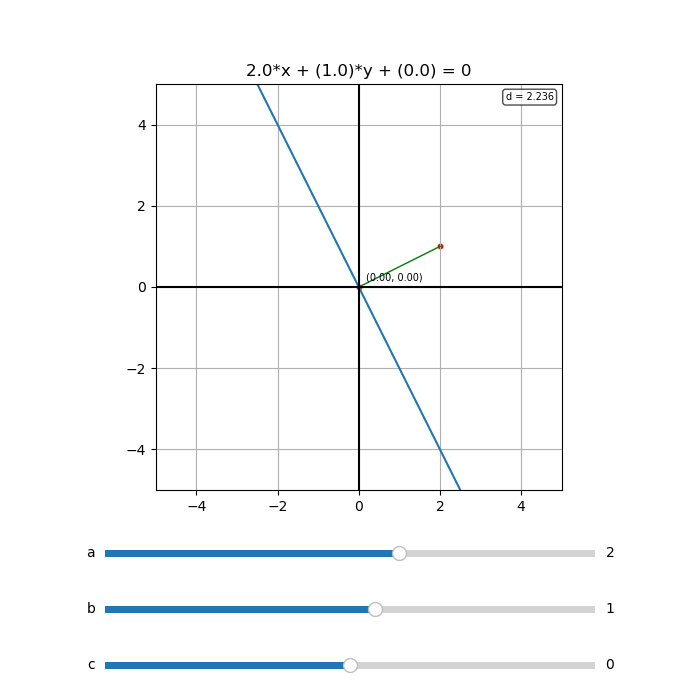

In [20]:
# the next thing a want to do is to plot this line
fig, ax = plt.subplots(figsize = (7, 7))
plt.subplots_adjust(bottom = 0.3)
oLine = ax.plot(
    vX,
    vX * vM[0] + vM[1]
)
ax.grid(True)
ax.scatter(
    pV[0], pV[1], s = 10, marker='o', color='red'
)
vC = point_projection(pV, vL_norm)
oProj_point = ax.scatter(
    vC[0], vC[1], s = 10, marker='o', color='red'
)
oProj_line = ax.plot([vC[0], pV[0]], [vC[1], pV[1]], lw = 1, color='green')
title = ax.set_title(f"{a_init}*x + ({b_init})*y + ({c_init}) = 0")

annot_point = ax.annotate( f"({vC[0]:.2f}, {vC[1]:.2f})", xy=vC, xytext=(5, 5), textcoords='offset points', color='k', fontsize=7)

annot_dist = ax.text(
    0.98, 0.98,
    f"d = {distance_to_point(pV, vL_norm):.3f}",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=7,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
)

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.set_aspect('equal')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

ax_a = plt.axes([0.15, 0.20, 0.7, 0.02])
a_slider = Slider(ax = ax_a, label='a', valmin=-10, valmax=10, valinit=a_init, valstep=0.5)

ax_b = plt.axes([0.15, 0.12, 0.7, 0.02])
b_slider = Slider(ax = ax_b, label='b', valmin=-10, valmax=10, valinit=b_init, valstep=0.5)

ax_c = plt.axes([0.15, 0.04, 0.7, 0.02])
c_slider = Slider(ax = ax_c, label='c', valmin=-10, valmax=10, valinit=c_init, valstep=0.5)

def on_change(_):
    a = (a_slider.val)
    b = (b_slider.val)
    c = (c_slider.val)
    vM, vL_norm = build_line_function(a=a, b=b, c=c)
    oLine[0].set_ydata(vX * vM[0] + vM[1])
    vC = point_projection(pV, vL_norm)
    oProj_point.set_offsets(vC)
    oProj_line[0].set_xdata([vC[0], pV[0]])
    oProj_line[0].set_ydata([vC[1], pV[1]])
    title.set_text(f"{a}*x + ({b})*y + ({c}) = 0")

    annot_point.xy = vC
    annot_point.set_text(f"({vC[0]:.2f}, {vC[1]:.2f})")
    annot_dist.set_text(f"d = {distance_to_point(pV, vL_norm):.3f}")

    fig.canvas.draw_idle()

a_slider.on_changed(on_change)
b_slider.on_changed(on_change)
c_slider.on_changed(on_change)
plt.show()